In [21]:
!pip install -q scikit-fuzzy
from google.colab import files
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d jeetblahiri/bccd-dataset-with-mask
!unzip -q bccd-dataset-with-mask.zip

Dataset URL: https://www.kaggle.com/datasets/jeetblahiri/bccd-dataset-with-mask
License(s): unknown
100% 2.14G/2.15G [00:37<00:00, 96.3MB/s]
100% 2.15G/2.15G [00:37<00:00, 61.7MB/s]


In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import skfuzzy as fuzz
from glob import glob

BASE = "BCCD Dataset with mask"

te_img_dir = os.path.join(BASE, "test", "original")
te_msk_dir = os.path.join(BASE, "test", "mask")

raw_te_imgs = glob(os.path.join(te_img_dir, "*"))
raw_te_msks = glob(os.path.join(te_msk_dir, "*"))

img_map = {os.path.splitext(os.path.basename(p))[0]: p for p in raw_te_imgs}
msk_map = {os.path.splitext(os.path.basename(p))[0]: p for p in raw_te_msks}

names = sorted(list(set(img_map.keys()) & set(msk_map.keys())))

te_imgs = [img_map[n] for n in names]
te_msks = [msk_map[n] for n in names]

In [23]:
def dice(p, g):
    inter = np.sum(p * g)
    if (np.sum(p) + np.sum(g)) == 0:
        return 1.0
    return (2.0 * inter) / (np.sum(p) + np.sum(g))


def prep(ip, mp, sz=(256, 256)):
    im = cv2.resize(cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB), sz)
    mk = cv2.resize(cv2.imread(mp, 0), sz, interpolation=cv2.INTER_NEAREST)
    mk = (mk > 0).astype(np.uint8)
    return im, mk


def kseg(im, k=3):
    px = im.reshape((-1, 3)).astype(np.float32)
    lb = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(px)
    return lb.reshape(im.shape[:2])


def fseg(im, c=3):
    px = im.reshape((-1, 3)).T.astype(np.float64)
    u = fuzz.cluster.cmeans(px, c=c, m=2, error=0.005, maxiter=300)[1]
    return np.argmax(u, axis=0).reshape(im.shape[:2])

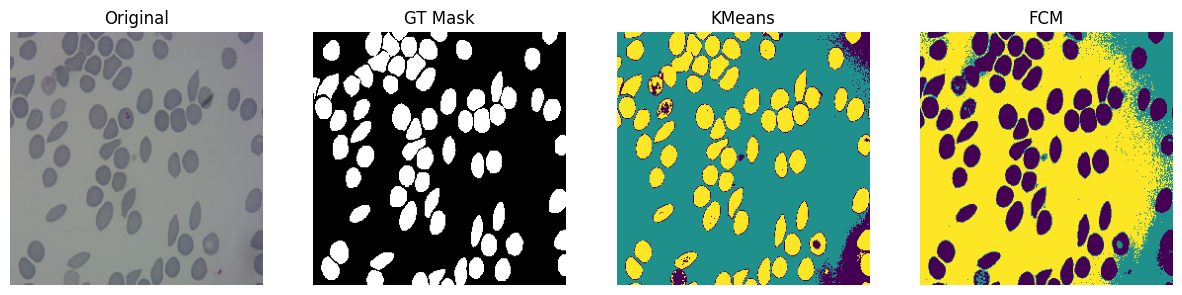

In [24]:
import random

idx = random.randint(0, len(te_imgs) - 1)

im, gt = prep(te_imgs[idx], te_msks[idx])

k_out = kseg(im)
f_out = fseg(im)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(im)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gt, cmap="gray")
plt.title("GT Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(k_out, cmap="viridis")
plt.title("KMeans")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(f_out, cmap="viridis")
plt.title("FCM")
plt.axis("off")

plt.show()

In [27]:
k_sc = []
f_sc = []

for i in range(len(te_imgs)):

    im, gt = prep(te_imgs[i], te_msks[i])

    k_out = kseg(im)
    f_out = fseg(im)


    best_k = 0
    for cid in np.unique(k_out):
        cand = (k_out == cid).astype(np.uint8)
        sc = dice(cand, gt)
        if sc > best_k:
            best_k = sc
    k_sc.append(best_k)


    best_f = 0
    for cid in np.unique(f_out):
        cand = (f_out == cid).astype(np.uint8)
        sc = dice(cand, gt)
        if sc > best_f:
            best_f = sc
    f_sc.append(best_f)

In [28]:
print(f"KMeans Dice Score: {np.mean(k_sc):.4f}")
print(f"FCM Dice Score: {np.mean(f_sc):.4f}")

KMeans Dice Score: 0.7601
FCM Dice Score: 0.7436
